# Hugging Face Yelp Emotion Classification: Selected Business Emotion Dashboard Outputs

This notebook applies the Hugging Face model `j-hartmann/emotion-english-distilroberta-base` to Yelp review text, stores review-level emotion probabilities, and then produces emotion-only outputs for a selected business name.

The seven emotions are:

- anger
- disgust
- fear
- joy
- neutral
- sadness
- surprise




## 1. Mount Google Drive

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


## 2. Install required packages

In [ ]:
!pip install -q transformers torch accelerate tqdm

## 3. Import libraries

In [2]:
import os
import gc
import json
import time

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch

from tqdm.auto import tqdm
from transformers import pipeline

## 4. Set file paths

In [3]:
input_path = "/content/drive/MyDrive/yelp_reviews_clean_CA.csv"

review_level_output_path = (
    "/content/drive/MyDrive/yelp_reviews_with_hf_emotions.csv"
)

all_business_summary_output_path = (
    "/content/drive/MyDrive/yelp_all_business_emotion_summary.csv"
)

selected_business_average_output_path = (
    "/content/drive/MyDrive/yelp_selected_business_average_emotions.csv"
)

plot_folder = "/content/drive/MyDrive/yelp_selected_business_emotion_plots"
os.makedirs(plot_folder, exist_ok=True)

print("Input file:", input_path)
print("Review-level output:", review_level_output_path)
print("All-business summary output:", all_business_summary_output_path)
print("Selected-business average output:", selected_business_average_output_path)
print("Plot folder:", plot_folder)

Input file: /content/drive/MyDrive/yelp_reviews_clean_CA.csv
Review-level output: /content/drive/MyDrive/yelp_reviews_with_hf_emotions.csv
All-business summary output: /content/drive/MyDrive/yelp_all_business_emotion_summary.csv
Selected-business average output: /content/drive/MyDrive/yelp_selected_business_average_emotions.csv
Plot folder: /content/drive/MyDrive/yelp_selected_business_emotion_plots


## 5. Define emotion labels

In [4]:
target_emotions = [
    "anger",
    "disgust",
    "fear",
    "joy",
    "neutral",
    "sadness",
    "surprise"
]

## 6. Load the Hugging Face emotion-classification model

In [5]:
device = 0 if torch.cuda.is_available() else -1

print("Using device:", "GPU" if device == 0 else "CPU")

emotion_classifier = pipeline(
    task="text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    top_k=None,
    truncation=True,
    device=device
)

Using device: GPU


config.json:   0%|          | 0.00/1.00k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  329MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

...

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  329MB            

model.safetensors: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

## 7. Test the model on one sentence

In [6]:
test_text = "The food was excellent, but the service was very slow and frustrating."

test_result = emotion_classifier(test_text)

print(test_result)

[[{'label': 'sadness', 'score': 0.6139369606971741}, {'label': 'neutral', 'score': 0.14421696960926056}, {'label': 'disgust', 'score': 0.14336302876472473}, {'label': 'anger', 'score': 0.07160086184740067}, {'label': 'surprise', 'score': 0.01388348825275898}, {'label': 'fear', 'score': 0.009092110209167004}, {'label': 'joy', 'score': 0.003906577825546265}]]


## 8. Helper functions for emotion extraction

In [7]:
def normalize_hf_output(prediction):
    """
    Converts Hugging Face pipeline output into a dictionary with all seven emotion scores.

    Expected output shape for one text:
    [
        {'label': 'joy', 'score': 0.71},
        {'label': 'neutral', 'score': 0.12},
        ...
    ]

    Some pipeline versions wrap the result in an extra list, so this function handles both cases.
    """

    if isinstance(prediction, list) and len(prediction) == 1 and isinstance(prediction[0], list):
        prediction = prediction[0]

    scores = {emotion: np.nan for emotion in target_emotions}

    for item in prediction:
        label = item["label"].lower()
        score = float(item["score"])

        if label in scores:
            scores[label] = score

    return scores


def classify_texts_in_batches(texts, batch_size=32):
    """
    Runs the Hugging Face emotion model on a list of texts and returns
    a DataFrame with one row per text and one column per emotion.
    """

    cleaned_texts = [
        str(text).replace("\n", " ").strip() if pd.notna(text) else " "
        for text in texts
    ]

    cleaned_texts = [
        text if text else " "
        for text in cleaned_texts
    ]

    predictions = emotion_classifier(
        cleaned_texts,
        batch_size=batch_size,
        truncation=True
    )

    emotion_rows = [
        normalize_hf_output(prediction)
        for prediction in predictions
    ]

    return pd.DataFrame(emotion_rows)

## 9. Process Yelp reviews and save review-level emotion scores

In [8]:
chunk_size = 10_000
batch_size = 32

first_chunk = True
total_rows_processed = 0

required_columns = ["business_id", "business_name", "text"]

# Delete existing output so results are not duplicated
if os.path.exists(review_level_output_path):
    os.remove(review_level_output_path)

start_time = time.time()

reader = pd.read_csv(
    input_path,
    usecols=lambda col: col in required_columns,
    chunksize=chunk_size
)

for chunk_number, chunk in enumerate(reader, start=1):

    chunk = chunk.dropna(subset=["business_id", "business_name", "text"]).copy()

    emotion_df = classify_texts_in_batches(
        chunk["text"].tolist(),
        batch_size=batch_size
    )

    for emotion in target_emotions:
        chunk[emotion] = emotion_df[emotion].values

    # Optional compact dictionary column for each review
    chunk["emotion_breakdown"] = chunk[target_emotions].apply(
        lambda row: json.dumps({emotion: float(row[emotion]) for emotion in target_emotions}),
        axis=1
    )

    chunk.to_csv(
        review_level_output_path,
        mode="w" if first_chunk else "a",
        header=first_chunk,
        index=False,
        encoding="utf-8"
    )

    first_chunk = False
    total_rows_processed += len(chunk)

    elapsed_minutes = (time.time() - start_time) / 60

    print(
        f"Chunk {chunk_number}: processed {len(chunk):,} rows; "
        f"total processed {total_rows_processed:,}; "
        f"elapsed {elapsed_minutes:.2f} minutes"
    )

    del chunk, emotion_df
    gc.collect()

print("Review-level emotion classification completed.")
print("Output saved to:", review_level_output_path)


Chunk 1: processed 10,000 rows; total processed 10,000; elapsed 2.05 minutes
Chunk 2: processed 10,000 rows; total processed 20,000; elapsed 4.31 minutes
Chunk 3: processed 10,000 rows; total processed 30,000; elapsed 6.65 minutes
Chunk 4: processed 10,000 rows; total processed 40,000; elapsed 8.96 minutes
Chunk 5: processed 10,000 rows; total processed 50,000; elapsed 11.18 minutes
Chunk 6: processed 10,000 rows; total processed 60,000; elapsed 13.44 minutes
Chunk 7: processed 10,000 rows; total processed 70,000; elapsed 15.72 minutes
Chunk 8: processed 10,000 rows; total processed 80,000; elapsed 17.82 minutes


[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Chunk 9: processed 10,000 rows; total processed 90,000; elapsed 20.05 minutes
Chunk 10: processed 10,000 rows; total processed 100,000; elapsed 22.43 minutes
Chunk 11: processed 10,000 rows; total processed 110,000; elapsed 24.75 minutes
Chunk 12: processed 10,000 rows; total processed 120,000; elapsed 27.04 minutes
Chunk 13: processed 10,000 rows; total processed 130,000; elapsed 29.39 minutes
Chunk 14: processed 10,000 rows; total processed 140,000; elapsed 31.65 minutes
Chunk 15: processed 10,000 rows; total processed 150,000; elapsed 33.96 minutes
Chunk 16: processed 10,000 rows; total processed 160,000; elapsed 36.35 minutes
Chunk 17: processed 10,000 rows; total processed 170,000; elapsed 38.69 minutes
Chunk 18: processed 10,000 rows; total processed 180,000; elapsed 40.95 minutes
Chunk 19: processed 10,000 rows; total processed 190,000; elapsed 43.18 minutes
Chunk 20: processed 10,000 rows; total processed 200,000; elapsed 45.54 minutes
Chunk 21: processed 10,000 rows; total pro

## 10. Load review-level emotion output for aggregation

In [9]:
emotion_data = pd.read_csv(
    review_level_output_path,
    usecols=lambda col: col in (["business_id", "business_name"] + target_emotions)
)

print("Loaded rows:", len(emotion_data))
display(emotion_data.head())


Loaded rows: 347328


,business_id,business_name,anger,disgust,fear,joy,neutral,sadness,surprise
0,B5XSoSG3SfvQGtKEGQ1tSQ,Los Padres National Forest,0.008734,0.822872,0.004067,0.002275,0.120224,0.035283,0.006545
1,gebiRewfieSdtt17PTW6Zg,Hibachi Steak House & Sushi Bar,0.002274,0.000808,0.001042,0.010908,0.012356,0.001590,0.971022
2,vC2qm1y3Au5czBtbhc-DNw,Sushi Teri,0.006868,0.011034,0.001111,0.527907,0.430451,0.004687,0.017942
3,bbEXAEFr4RYHLlZ-HFssTA,The Original Habit Burger Grill,0.002327,0.009085,0.002525,0.686066,0.268133,0.010192,0.021671
4,IDtLPgUrqorrpqSLdfMhZQ,Helena Avenue Bakery,0.002102,0.004804,0.001247,0.849211,0.100212,0.003524,0.038900


## 11. Create and save all-business emotion summary by business name


In [10]:
# Create one business-level emotion summary row per business_name.
# If the same business_name appears across multiple business_id values/locations,
# this combines all matching reviews into one business-name-level summary.

emotion_data["business_name_clean"] = (
    emotion_data["business_name"]
    .astype(str)
    .str.strip()
)

# Remove empty business names, if any
emotion_data = emotion_data[
    emotion_data["business_name_clean"].ne("")
].copy()

# Average emotion probabilities per business name
business_avg = (
    emotion_data
    .groupby("business_name_clean", dropna=False)[target_emotions]
    .mean()
    .reset_index()
)

# Number of reviews per business name
business_review_counts = (
    emotion_data
    .groupby("business_name_clean", dropna=False)
    .size()
    .reset_index(name="review_count")
)

# Number of unique business_id values/locations per business name
business_id_counts = (
    emotion_data
    .groupby("business_name_clean", dropna=False)["business_id"]
    .nunique()
    .reset_index(name="matching_business_id_count")
)

# Combine all business-name-level outputs
business_summary = (
    business_review_counts
    .merge(business_id_counts, on="business_name_clean", how="left")
    .merge(business_avg, on="business_name_clean", how="left")
    .rename(columns={"business_name_clean": "business_name"})
)

business_summary = business_summary[
    ["business_name", "matching_business_id_count", "review_count"] + target_emotions
]

business_summary.to_csv(
    all_business_summary_output_path,
    index=False,
    encoding="utf-8"
)

print("All-business emotion summary saved to:", all_business_summary_output_path)
print("Number of unique business names:", len(business_summary))

display(business_summary.head())



All-business emotion summary saved to: /content/drive/MyDrive/yelp_all_business_emotion_summary.csv
Number of unique business names: 4855


,business_name,matching_business_id_count,review_count,anger,disgust,fear,joy,neutral,sadness,surprise
0,'O' Bar + Kitchen,1,28,0.008568,0.120163,0.019607,0.474069,0.249569,0.049040,0.078984
1,1-800-GOT-JUNK? Central Coast,1,25,0.019161,0.027138,0.039789,0.346290,0.442290,0.011893,0.113440
2,1-800-GOT-JUNK? Santa Barbara,1,14,0.119288,0.015260,0.008298,0.368604,0.307219,0.030961,0.150370
3,101 Deli,1,28,0.015960,0.035296,0.005824,0.429038,0.301331,0.014925,0.197626
4,101 Property Mgmt,1,8,0.006282,0.004992,0.003001,0.631401,0.291428,0.005335,0.057562


## 12. Select one business by business name


In [11]:
# Manually set the business name to analyze
selected_business_name = "Iron Horse Auto Body"

# Match the business name case-insensitively and ignore leading/trailing spaces
selected_business_reviews = emotion_data[
    emotion_data["business_name"].astype(str).str.strip().str.lower()
    == selected_business_name.strip().lower()
].copy()

if selected_business_reviews.empty:
    raise ValueError(
        f"No reviews found for business_name = '{selected_business_name}'. "
        "Check the spelling or inspect emotion_data['business_name'].value_counts().head()."
    )

selected_review_count = len(selected_business_reviews)
selected_business_ids = sorted(selected_business_reviews["business_id"].dropna().unique())
selected_location_count = len(selected_business_ids)

print("Selected business name:", selected_business_name)
print("Number of matching business_id values:", selected_location_count)
print("Number of reviews:", selected_review_count)
print("First 10 matching business_id values:", selected_business_ids[:10])

display(selected_business_reviews.head())


Selected business name: Iron Horse Auto Body
Number of matching business_id values: 1
Number of reviews: 32
First 10 matching business_id values: ['nUqrF-h9S7myCcvNDecOvw']


,business_id,business_name,anger,disgust,fear,joy,neutral,sadness,surprise,business_name_clean
587,nUqrF-h9S7myCcvNDecOvw,Iron Horse Auto Body,0.006868,0.001943,0.001494,0.847906,0.065126,0.002565,0.074098,Iron Horse Auto Body
630,nUqrF-h9S7myCcvNDecOvw,Iron Horse Auto Body,0.209610,0.029535,0.005123,0.047448,0.076372,0.036441,0.595471,Iron Horse Auto Body
2527,nUqrF-h9S7myCcvNDecOvw,Iron Horse Auto Body,0.009918,0.009951,0.006638,0.321642,0.614502,0.010616,0.026733,Iron Horse Auto Body
2812,nUqrF-h9S7myCcvNDecOvw,Iron Horse Auto Body,0.012372,0.007433,0.004215,0.192371,0.483026,0.021497,0.279086,Iron Horse Auto Body
4244,nUqrF-h9S7myCcvNDecOvw,Iron Horse Auto Body,0.004297,0.001121,0.001161,0.968435,0.013422,0.001824,0.009741,Iron Horse Auto Body


## 13. Filter the saved business-level summary and save selected-business average emotion distribution


In [12]:
# Since the all-business emotion summary was already saved by business_name,
# filter that summary instead of recomputing averages from review-level rows.

business_summary = pd.read_csv(all_business_summary_output_path)

selected_business_summary = business_summary[
    business_summary["business_name"].astype(str).str.strip().str.lower()
    == selected_business_name.strip().lower()
].copy()

if selected_business_summary.empty:
    raise ValueError(
        f"No precomputed business summary found for business_name = '{selected_business_name}'. "
        "Check the spelling or inspect business_summary['business_name'].value_counts().head()."
    )

# There should be one row because the summary is grouped by business_name.
selected_business_summary_row = selected_business_summary.iloc[0]

selected_review_count = int(selected_business_summary_row["review_count"])
selected_location_count = int(selected_business_summary_row["matching_business_id_count"])

selected_average_emotions = (
    selected_business_summary_row[target_emotions]
    .astype(float)
    .sort_values(ascending=False)
)

selected_average_emotions_df = selected_average_emotions.reset_index()
selected_average_emotions_df.columns = ["emotion", "average_score"]

selected_average_emotions_df["business_name"] = selected_business_name
selected_average_emotions_df["review_count"] = selected_review_count
selected_average_emotions_df["matching_business_id_count"] = selected_location_count

# Reorder columns
selected_average_emotions_df = selected_average_emotions_df[
    ["business_name", "matching_business_id_count", "review_count", "emotion", "average_score"]
]

selected_average_emotions_df.to_csv(
    selected_business_average_output_path,
    index=False,
    encoding="utf-8"
)

print("Average emotion distribution for selected business name from precomputed summary:")
display(selected_average_emotions_df)

max_average_emotion = selected_average_emotions.idxmax()
max_average_value = selected_average_emotions.max()

print("Emotion with highest average score:", max_average_emotion)
print("Highest average score:", max_average_value)
print("Saved selected-business average emotion distribution to:", selected_business_average_output_path)



Average emotion distribution for selected business name from precomputed summary:


,business_name,matching_business_id_count,review_count,emotion,average_score
0,Iron Horse Auto Body,1,32,joy,0.325750
1,Iron Horse Auto Body,1,32,neutral,0.316089
2,Iron Horse Auto Body,1,32,surprise,0.173268
3,Iron Horse Auto Body,1,32,anger,0.086697
4,Iron Horse Auto Body,1,32,sadness,0.053205
5,Iron Horse Auto Body,1,32,disgust,0.032244
6,Iron Horse Auto Body,1,32,fear,0.012747


Emotion with highest average score: joy
Highest average score: 0.3257498153107008
Saved selected-business average emotion distribution to: /content/drive/MyDrive/yelp_selected_business_average_emotions.csv


## 14. Plot average emotion distribution for the selected business

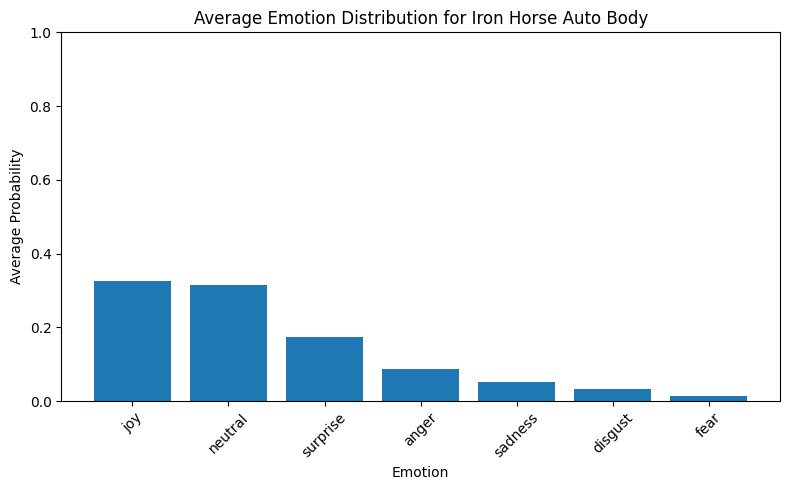

Saved: /content/drive/MyDrive/yelp_selected_business_emotion_plots/iron_horse_auto_body_average_emotion_distribution.png


In [13]:
safe_selected_business_name = (
    selected_business_name
    .strip()
    .lower()
    .replace(" ", "_")
    .replace("/", "_")
)

plt.figure(figsize=(8, 5))

plt.bar(
    selected_average_emotions_df["emotion"],
    selected_average_emotions_df["average_score"]
)

plt.title(f"Average Emotion Distribution for {selected_business_name}")
plt.xlabel("Emotion")
plt.ylabel("Average Probability")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()

average_plot_path = os.path.join(
    plot_folder,
    f"{safe_selected_business_name}_average_emotion_distribution.png"
)

plt.savefig(average_plot_path, dpi=300)
plt.show()

print("Saved:", average_plot_path)


## 15. Generate histograms for each emotion for the selected business

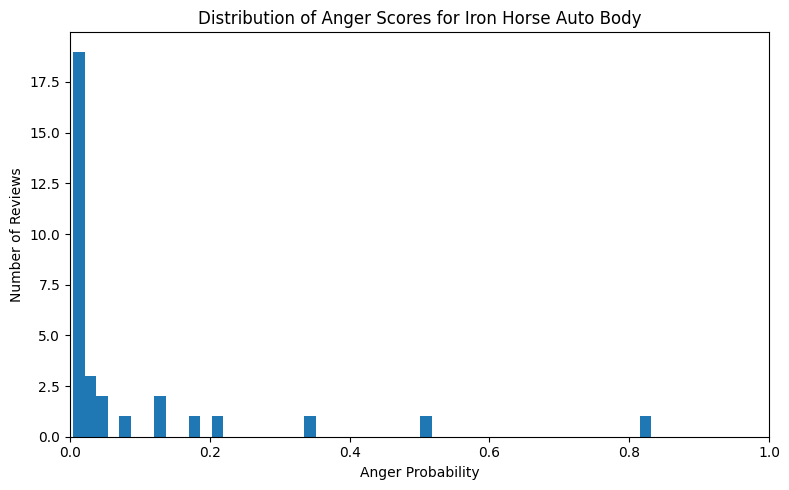

Saved: /content/drive/MyDrive/yelp_selected_business_emotion_plots/iron_horse_auto_body_anger_distribution_hf.png


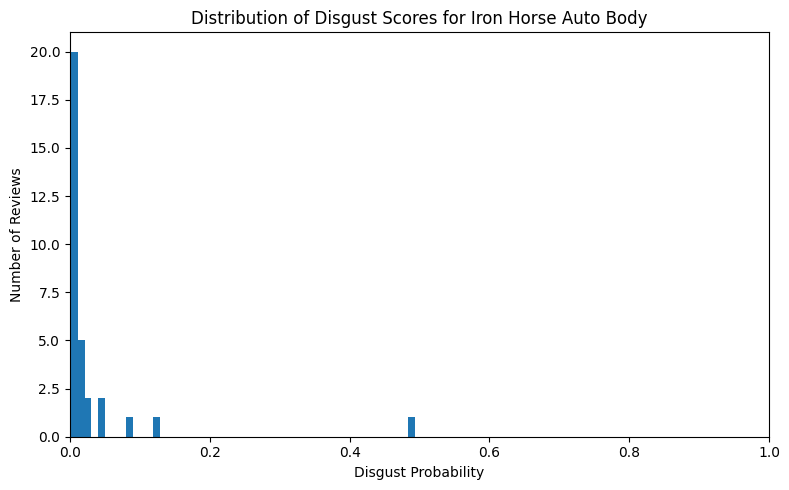

Saved: /content/drive/MyDrive/yelp_selected_business_emotion_plots/iron_horse_auto_body_disgust_distribution_hf.png


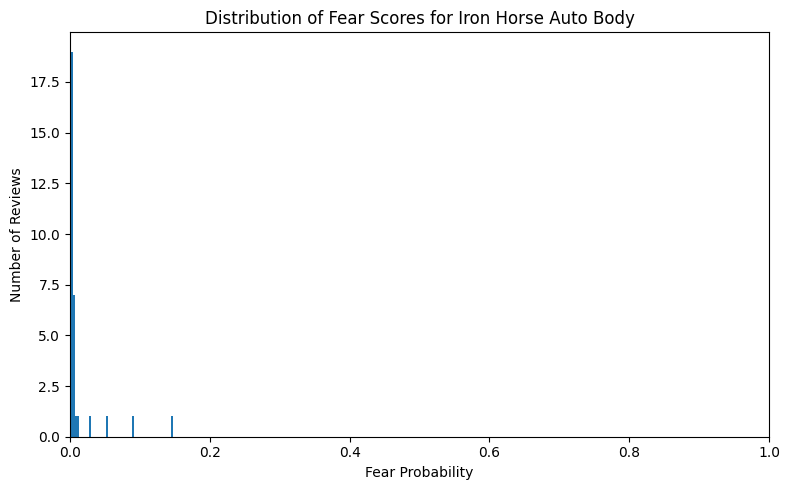

Saved: /content/drive/MyDrive/yelp_selected_business_emotion_plots/iron_horse_auto_body_fear_distribution_hf.png


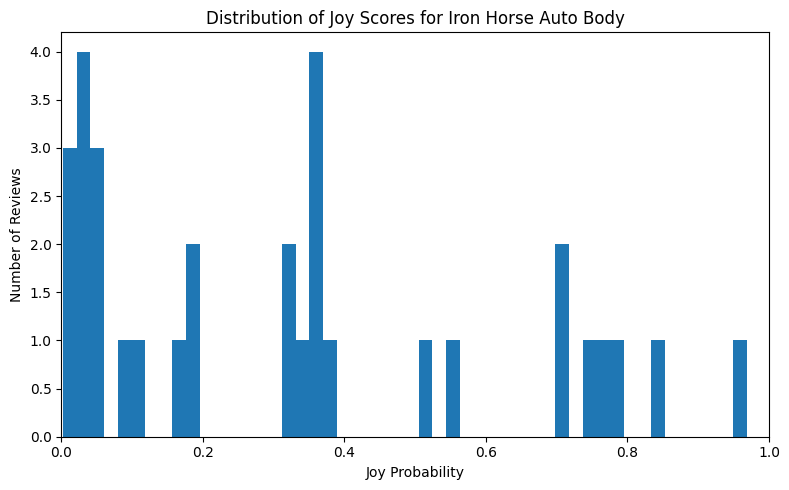

Saved: /content/drive/MyDrive/yelp_selected_business_emotion_plots/iron_horse_auto_body_joy_distribution_hf.png


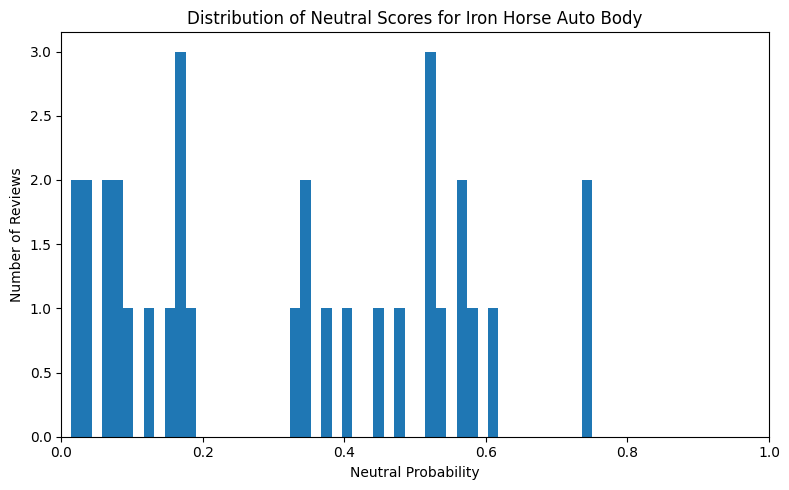

Saved: /content/drive/MyDrive/yelp_selected_business_emotion_plots/iron_horse_auto_body_neutral_distribution_hf.png


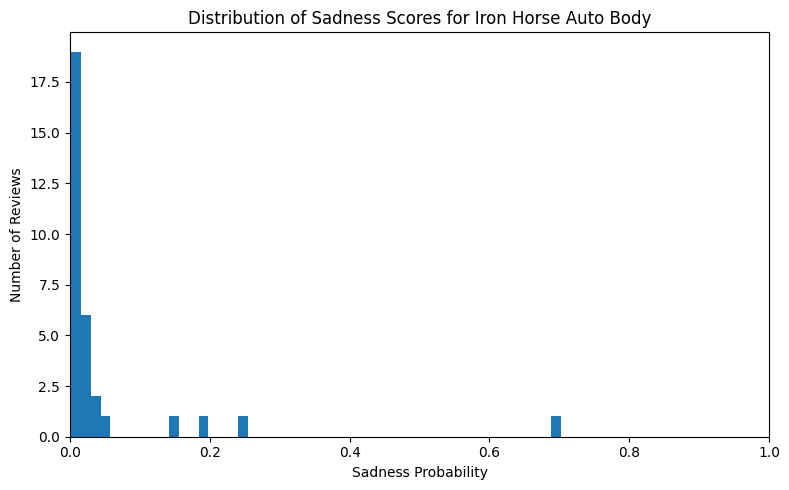

Saved: /content/drive/MyDrive/yelp_selected_business_emotion_plots/iron_horse_auto_body_sadness_distribution_hf.png


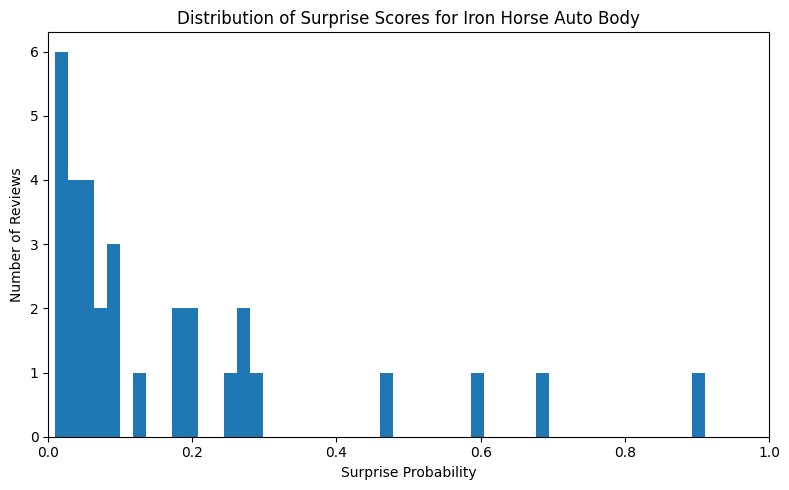

Saved: /content/drive/MyDrive/yelp_selected_business_emotion_plots/iron_horse_auto_body_surprise_distribution_hf.png


In [14]:
for emotion in target_emotions:
    plt.figure(figsize=(8, 5))

    plt.hist(
        selected_business_reviews[emotion].dropna(),
        bins=50
    )

    plt.title(f"Distribution of {emotion.capitalize()} Scores for {selected_business_name}")
    plt.xlabel(f"{emotion.capitalize()} Probability")
    plt.ylabel("Number of Reviews")
    plt.xlim(0, 1)
    plt.tight_layout()

    plot_path = os.path.join(
        plot_folder,
        f"{safe_selected_business_name}_{emotion}_distribution_hf.png"
    )

    plt.savefig(plot_path, dpi=300)
    plt.show()

    print("Saved:", plot_path)
